# Projet 3 — Backtesting d'une stratégie systématique
## Notebook 04 — Coûts de transaction, slippage et dimensionnement

**Rôle de cette phase.** Un backtest sans coûts est une fiction. On introduit ici les **frictions réelles** du trading et on mesure leur effet. Le résultat central, celui qui fait la différence sur un CV : **une stratégie n'est jugée qu'après coûts**, et l'ampleur de l'impact dépend directement du **turnover** (la fréquence de rotation du portefeuille).

On procède en trois temps :
1. le **modèle de coûts** (commission + slippage), inséré dans le moteur événementiel ;
2. l'effet sur le **SMA** (faible turnover) vs sur le **momentum** (fort turnover) — le contraste clé ;
3. le **dimensionnement** des positions (position sizing), au-delà du « tout ou rien ».


## 1. Le modèle de coûts

Deux frictions, exprimées en **points de base** (bps ; 1 bps = 0,01 %) :

- **Commission** — les frais de courtage, proportionnels au montant échangé. Pour des actions US très liquides via un courtier discount, l'ordre de grandeur réaliste est de **1 à 5 bps** par transaction.
- **Slippage** — l'écart entre le cours affiché et le prix réellement obtenu. On achète un peu plus cher et on vend un peu moins cher, car passer un ordre consomme de la liquidité. Sur des large caps liquides, **quelques bps** ; davantage sur des titres peu échangés.

Ces deux coûts sont insérés **uniquement** dans `SimulatedExecutionHandler` (`execution.py`), sans toucher au reste du moteur — c'est le bénéfice concret du découplage. Le slippage dégrade le **prix d'exécution** ; la commission s'ajoute par-dessus.


In [12]:
import sys, queue
sys.path.insert(0, "../src")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (11, 4.5); plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3

from data import HistoricCSVDataHandler
from strategy import MovingAverageCrossStrategy
from portfolio import Portfolio
from execution import SimulatedExecutionHandler
from backtest import run_backtest

prices = pd.read_csv("../data/adj_close.csv", index_col=0, parse_dates=True)
print("Données réelles :", prices.shape, "|", prices.index.min().date(), "->", prices.index.max().date())

Données réelles : (4177, 11) | 2010-01-04 -> 2026-08-12


In [13]:
def run_sma(symbol_list, short=50, long=200, commission_bps=0.0, slippage_bps=0.0,
            initial_capital=100_000.0, target_pct=0.95):
    ev = queue.Queue()
    d = HistoricCSVDataHandler(ev, prices, symbol_list); d.events = ev
    s = MovingAverageCrossStrategy(d, ev, symbol_list, short, long)
    p = Portfolio(d, ev, symbol_list, prices.index[0], initial_capital, target_pct)
    x = SimulatedExecutionHandler(d, ev, commission_bps, slippage_bps)
    ec = run_backtest(d, s, p, x)
    return ec

def metrics(ec, ann=252):
    r = ec["returns"].dropna(); eq = ec["equity"]; years = len(r) / ann
    return {"Équité finale": eq.iloc[-1], "CAGR": eq.iloc[-1] ** (1/years) - 1,
            "Sharpe": r.mean()/r.std()*np.sqrt(ann),
            "Max drawdown": (eq/eq.cummax()-1).min()}

UNIVERSE_SMA = ["AAPL", "MSFT", "NVDA", "AMZN", "JPM", "XOM", "JNJ", "PG"]

## 2. Effet des coûts sur le SMA (faible turnover)

On lance le croisement 50/200 sur AAPL, sans coût puis avec des coûts croissants. Le SMA change rarement de position (un aller-retour ne se produit qu'à chaque croisement, soit une poignée de fois en seize ans), donc on s'attend à un impact **minime**.


In [14]:
SYM = ["AAPL"]
scenarios = {"Sans coût": (0, 0), "1 bps + 2 bps": (1, 2),
             "5 bps + 5 bps": (5, 5), "10 bps + 10 bps": (10, 10)}
rows = {}
curves = {}
for label, (cb, sb) in scenarios.items():
    ec = run_sma(SYM, 50, 200, cb, sb)
    rows[label] = metrics(ec)
    curves[label] = ec["equity"]

# nombre de trades
pos = ec["pos_AAPL"]; n_trades = int((pos.diff().abs() > 0).sum())
print(f"Nombre de changements de position sur toute la période : {n_trades}")
pd.DataFrame(rows).T.round(4)

Nombre de changements de position sur toute la période : 15


,Équité finale,CAGR,Sharpe,Max drawdown
Sans coût,12.0269,0.1619,0.7748,-0.4441
1 bps + 2 bps,11.9805,0.1617,0.7736,-0.4444
5 bps + 5 bps,11.8746,0.1610,0.7710,-0.4453
10 bps + 10 bps,11.7257,0.1602,0.7672,-0.4466


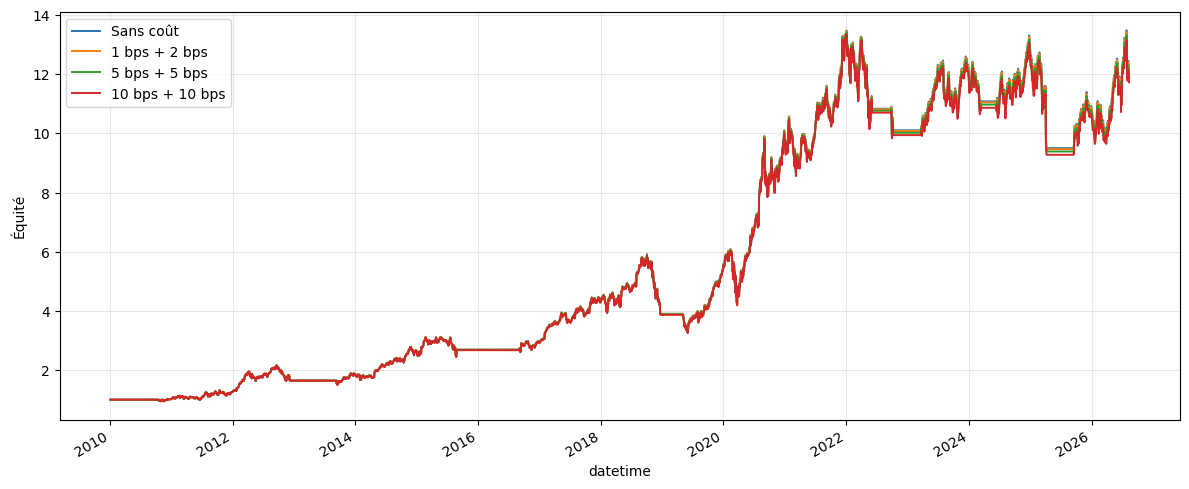

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
for label, eq in curves.items():
    eq.plot(ax=ax, label=label, lw=1.4)
ax.set_title("")
ax.set_ylabel("Équité"); ax.legend(); plt.tight_layout(); plt.show()

### Vérification sur tout l'univers (et pas seulement AAPL)

Montrer le résultat sur un seul titre pourrait laisser croire qu'AAPL a été choisi parce qu'il arrangeait la démonstration. On répète donc l'analyse sur **les 8 titres** de l'univers momentum, avec des coûts de 10 bps + 10 bps, et on regarde le turnover (nombre de changements de position) et la perte de Sharpe titre par titre, puis en moyenne.


In [16]:
rows = []
for t in UNIVERSE_SMA:
    g = run_sma([t], 50, 200, 0, 0)
    n = run_sma([t], 50, 200, 10, 10)
    pos = g[f"pos_{t}"]; n_chg = int((pos.diff().abs() > 0).sum())
    sg, sn = metrics(g)["Sharpe"], metrics(n)["Sharpe"]
    rows.append({"Ticker": t, "Changements de position": n_chg,
                 "Sharpe brut": sg, "Sharpe net": sn, "Δ Sharpe": sn - sg})
sma_uni = pd.DataFrame(rows).set_index("Ticker")
print("Moyennes — Sharpe brut : {:.3f} | net : {:.3f} | Δ moyen : {:.4f} | changements moyens : {:.1f}".format(
    sma_uni["Sharpe brut"].mean(), sma_uni["Sharpe net"].mean(),
    sma_uni["Δ Sharpe"].mean(), sma_uni["Changements de position"].mean()))
sma_uni.round(3)

Moyennes — Sharpe brut : 0.644 | net : 0.631 | Δ moyen : -0.0127 | changements moyens : 20.4


,Changements de position,Sharpe brut,Sharpe net,Δ Sharpe
Ticker,,,,
AAPL,15,0.775,0.767,-0.008
MSFT,20,0.786,0.775,-0.011
NVDA,13,1.170,1.166,-0.004
AMZN,19,0.644,0.635,-0.008
JPM,17,0.625,0.615,-0.010
XOM,25,0.424,0.407,-0.017
JNJ,27,0.437,0.416,-0.022
PG,27,0.291,0.269,-0.022


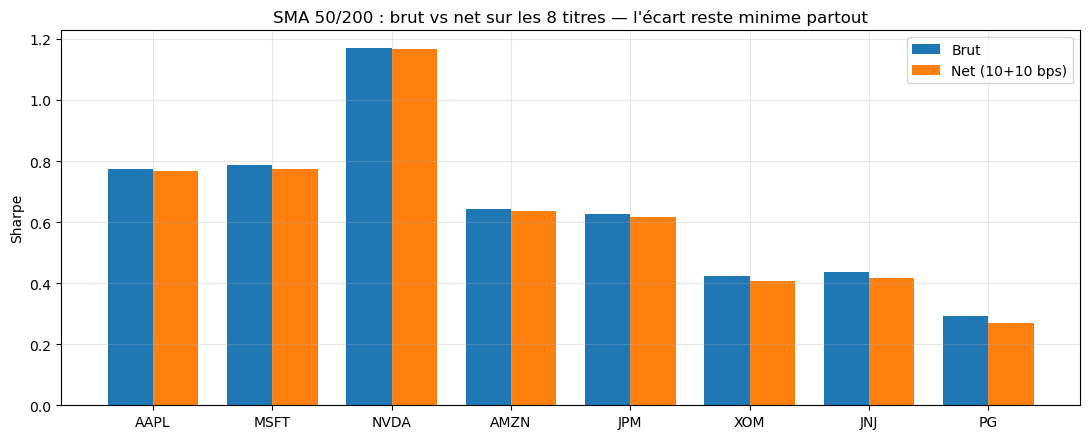

In [17]:
fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(sma_uni)); wdt = 0.38
ax.bar(x - wdt/2, sma_uni["Sharpe brut"], wdt, label="Brut", color="tab:blue")
ax.bar(x + wdt/2, sma_uni["Sharpe net"], wdt, label="Net (10+10 bps)", color="tab:orange")
ax.set_xticks(x); ax.set_xticklabels(sma_uni.index); ax.set_ylabel("Sharpe")
ax.set_title("SMA 50/200 : brut vs net sur les 8 titres — l'écart reste minime partout")
ax.legend(); plt.tight_layout(); plt.show()

L'écart brut/net est faible sur **chaque** titre, pas seulement AAPL : le SMA change de position une vingtaine de fois en seize ans, donc son turnover est structurellement bas. La conclusion tient sur tout l'univers, ce qui la rend défendable dans le rapport.


## 3. Effet des coûts sur le momentum (fort turnover)

Le momentum reclasse le portefeuille **chaque mois** et remplace souvent plusieurs positions : son turnover est élevé, donc sa sensibilité aux coûts aussi. On mesure la performance **brute** (avant coûts) et **nette** (après coûts) pour chaque fenêtre de lookback.

**Le turnover**, ici, est la somme des variations de poids à chaque rééquilibrage : \( \text{turnover}_t = \sum_i |w_{i,t} - w_{i,t-1}| \). Un turnover de 1,0 signifie qu'on renouvelle en moyenne 100 % du portefeuille à chaque période. Le coût d'un rééquilibrage vaut turnover × (commission + slippage).


In [18]:
UNIVERSE = ["AAPL", "MSFT", "NVDA", "AMZN", "JPM", "XOM", "JNJ", "PG"]
mpx = prices[UNIVERSE].resample("ME").last()
mret = mpx.pct_change()
WINDOWS = [1, 3, 6, 12]; TOP_K = 3; COST_BPS = 20  # commission + slippage cumulés

def perf_m(r, ann=12):
    r = r.dropna(); eq = (1+r).cumprod(); yrs = len(r)/ann
    return {"CAGR": eq.iloc[-1]**(1/yrs)-1, "Sharpe": r.mean()/r.std()*np.sqrt(ann),
            "Max drawdown": (eq/eq.cummax()-1).min(), "Équité finale": eq.iloc[-1]}

def cs_momentum(N, cost_bps=0):
    lb = mpx.pct_change(N); ranks = lb.rank(axis=1, ascending=False)
    w = (ranks <= TOP_K).astype(float); w = w.div(w.sum(axis=1), axis=0).fillna(0)
    gross = (w.shift(1) * mret).sum(axis=1)
    turnover = (w - w.shift(1)).abs().sum(axis=1)
    cost = turnover.shift(1) * cost_bps / 1e4
    net = gross - cost
    return gross.iloc[N+1:], net.iloc[N+1:], turnover.iloc[N+1:].mean()

rows = []
for N in WINDOWS:
    g, n, to = cs_momentum(N, COST_BPS)
    pg, pn = perf_m(g), perf_m(n)
    rows.append({"Fenêtre": f"{N} mois", "Turnover/mois": to,
                 "Sharpe brut": pg["Sharpe"], "Sharpe net": pn["Sharpe"],
                 "Δ Sharpe": pn["Sharpe"] - pg["Sharpe"],
                 "CAGR brut": pg["CAGR"], "CAGR net": pn["CAGR"]})
mom = pd.DataFrame(rows).set_index("Fenêtre")
print(f"Momentum cross-sectional, coûts = {COST_BPS} bps par unité de turnover")
mom.round(3)

Momentum cross-sectional, coûts = 20 bps par unité de turnover


,Turnover/mois,Sharpe brut,Sharpe net,Δ Sharpe,CAGR brut,CAGR net
Fenêtre,,,,,,
1 mois,1.199,1.372,1.231,-0.141,0.296,0.260
3 mois,0.629,1.432,1.363,-0.069,0.325,0.306
6 mois,0.449,1.368,1.319,-0.049,0.300,0.286
12 mois,0.360,1.243,1.201,-0.042,0.261,0.250


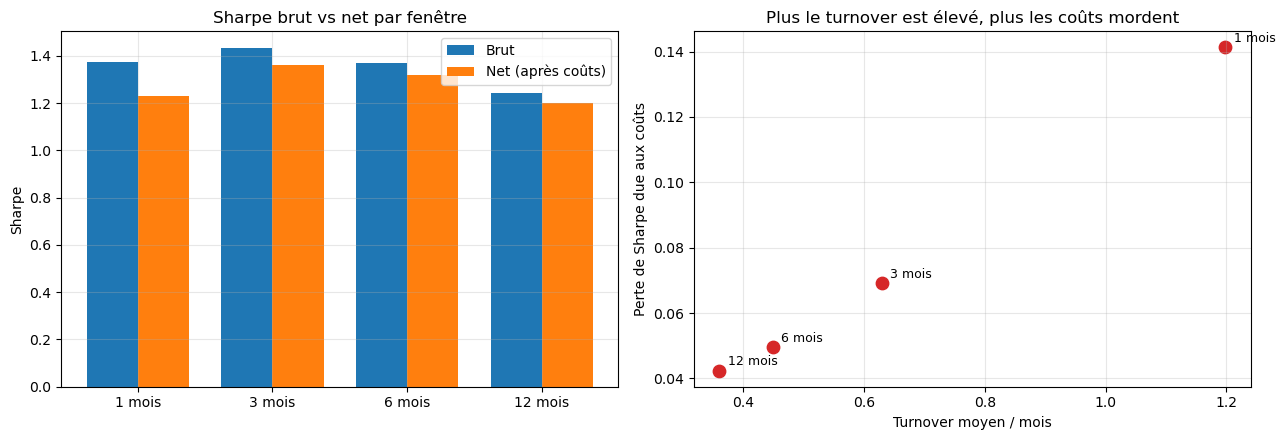

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(mom)); wdt = 0.38
axes[0].bar(x - wdt/2, mom["Sharpe brut"], wdt, label="Brut", color="tab:blue")
axes[0].bar(x + wdt/2, mom["Sharpe net"], wdt, label="Net (après coûts)", color="tab:orange")
axes[0].set_xticks(x); axes[0].set_xticklabels(mom.index); axes[0].set_ylabel("Sharpe")
axes[0].set_title("Sharpe brut vs net par fenêtre"); axes[0].legend()

axes[1].scatter(mom["Turnover/mois"], -mom["Δ Sharpe"], s=80, color="tab:red")
for i, lab in enumerate(mom.index):
    axes[1].annotate(lab, (mom["Turnover/mois"].iloc[i], -mom["Δ Sharpe"].iloc[i]),
                     textcoords="offset points", xytext=(6, 4), fontsize=9)
axes[1].set_xlabel("Turnover moyen / mois"); axes[1].set_ylabel("Perte de Sharpe due aux coûts")
axes[1].set_title("Plus le turnover est élevé, plus les coûts mordent")
plt.tight_layout(); plt.show()

### La leçon centrale

Le tableau et le nuage de points disent la même chose : **les coûts frappent proportionnellement au turnover**. La fenêtre la plus courte (1 mois) tourne le plus et perd le plus de Sharpe ; les fenêtres longues, plus lentes, résistent bien mieux. Le SMA, lui, est quasiment insensible aux coûts, car il ne bouge presque jamais.

Conséquence pratique pour le choix de stratégie : **on sélectionne sur le Sharpe NET, pas brut**. Une stratégie brute légèrement meilleure mais très gourmande en turnover peut se retrouver derrière une stratégie plus calme une fois les coûts payés. C'est exactement le genre d'arbitrage qu'un desk regarde.


In [20]:
best_net = mom["Sharpe net"].idxmax()
print(f"Meilleure fenêtre momentum APRÈS coûts (Sharpe net) : {best_net}")
print(mom.loc[best_net].round(3).to_string())

Meilleure fenêtre momentum APRÈS coûts (Sharpe net) : 3 mois
Turnover/mois    0.629
Sharpe brut      1.432
Sharpe net       1.363
Δ Sharpe        -0.069
CAGR brut        0.325
CAGR net         0.306


## 4. Le dimensionnement des positions (position sizing)

Jusqu'ici le portefeuille était « tout ou rien » (≈ 95 % investi ou à l'écart). C'est simple mais fruste : on prend autant de risque sur un titre calme que sur un titre très volatil. Deux approches standard vont plus loin.

- **Fraction fixe** : on investit une part constante du capital par position (ce qu'on fait déjà, en gros).
- **Volatility targeting** : on ajuste la taille pour viser une **volatilité cible** constante. On réduit l'exposition quand le marché est agité, on l'augmente quand il est calme. L'idée : stabiliser le risque plutôt que le montant investi.

On illustre le volatility targeting en version vectorielle sur AAPL. La position n'est plus 0/1 mais un levier \( \ell_t = \sigma_{\text{cible}} / \sigma_t \), où \( \sigma_t \) est la volatilité récente estimée. On plafonne le levier à 1 (pas d'effet de levier réel ici).


In [21]:
px = prices["AAPL"]
ret = px.pct_change()
ma_s, ma_l = px.rolling(50).mean(), px.rolling(200).mean()
raw_signal = pd.Series(np.where(ma_s > ma_l, 1.0, 0.0), index=px.index).shift(1)

# Volatility targeting
TARGET_VOL = 0.15  # 15% annualisé
realized_vol = ret.rolling(20).std() * np.sqrt(252)
leverage = (TARGET_VOL / realized_vol).clip(upper=1.0).shift(1)  # shift = anti look-ahead

strat_fixed = (raw_signal * ret).dropna()
strat_voltgt = (raw_signal * leverage * ret).dropna()

def q(r, ann=252):
    r = r.dropna()
    return {"Sharpe": r.mean()/r.std()*np.sqrt(ann),
            "Vol réalisée": r.std()*np.sqrt(ann),
            "Équité finale": (1+r).prod()}

comp = pd.DataFrame({"Tout ou rien (fraction fixe)": q(strat_fixed),
                     "Volatility targeting 15%": q(strat_voltgt)}).T
comp.round(3)

,Sharpe,Vol réalisée,Équité finale
Tout ou rien (fraction fixe),0.780,0.235,13.200
Volatility targeting 15%,0.922,0.143,7.407


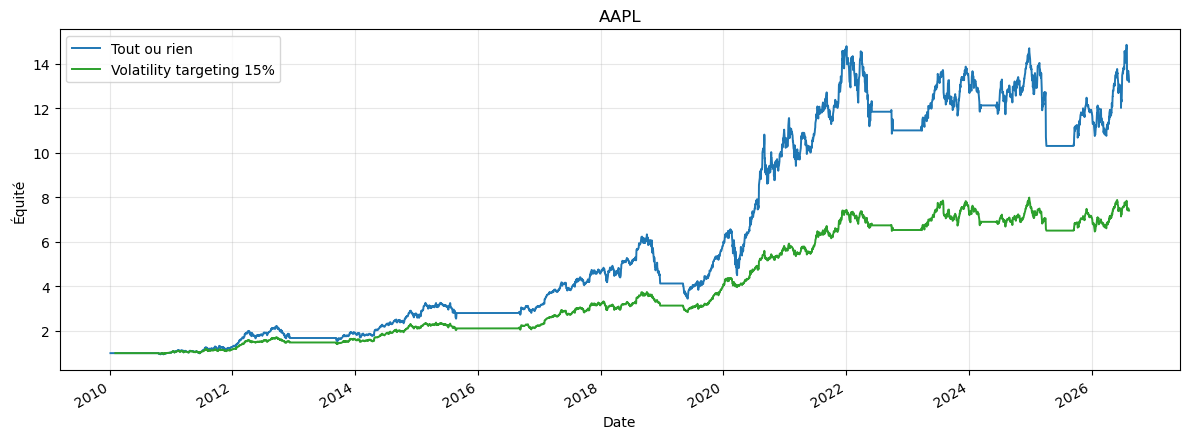

In [22]:
fig, ax = plt.subplots(figsize=(12, 4.5))
(1+strat_fixed).cumprod().plot(ax=ax, label="Tout ou rien", color="tab:blue", lw=1.4)
(1+strat_voltgt).cumprod().plot(ax=ax, label="Volatility targeting 15%", color="tab:green", lw=1.4)
ax.set_title("AAPL")
ax.set_ylabel("Équité"); ax.legend(); plt.tight_layout(); plt.show()

**Lecture.** Le volatility targeting ne cherche pas forcément plus de rendement, mais un **risque plus stable** : la volatilité réalisée se rapproche de la cible, et le profil de drawdown est souvent plus doux. C'est une brique que les desks systématiques utilisent partout. Dans notre projet, on la garde en démonstration ; le moteur événementiel conserve le dimensionnement « fraction fixe » pour la comparaison finale, mais on mentionnera cette extension dans le rapport.

## 5. Récapitulatif et prochaine étape

- Les coûts sont modélisés **au bon endroit** (l'ExecutionHandler), sans casser le reste ni la validation croisée.
- L'impact des coûts est **piloté par le turnover** : négligeable pour le SMA, significatif pour le momentum rapide.
- On sélectionne désormais les stratégies sur leur performance **nette**.
- Le **volatility targeting** offre un dimensionnement plus fin, à mentionner comme extension.

**Prochaine étape — Phase 4 : le pairs trading KO/PEP** (retour à la moyenne, long-short), plus l'intégration de la meilleure stratégie momentum dans le moteur événementiel, en vue de la comparaison finale.
